In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from skfda.representation.grid import FDataGrid
from skfda.preprocessing.dim_reduction.feature_extraction import FPCA
from sklearn.decomposition import PCA
import gc
import glob  
import pandas as pd
pd.options.mode.copy_on_write = True
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
import pathos.pools
from functools import partial
import os
import math
from  matplotlib.ticker import PercentFormatter
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
# set dask dashboard
import dask
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
#from dask.distributed import Client
#client = Client()  # start distributed scheduler locally.
#client
import matplotlib.cm as cm
from scipy.stats import t, ttest_rel
from scipy.ndimage import label

from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter1d
import re
import random


# Select modalities, events, parameters

In [36]:
# List with optional commented-out modalities
modalities = [
    'NoseVector.x',        
    'NoseVector.y',          
    'EyeDirWorldCombined.x', 
    'EyeDirWorldCombined.y',  
    #'EyeDirLocalCombined.x',        
    #'EyeDirLocalCombined.y',        
    'SteeringInput',         
]


# --- Toggle events by commenting them out ---
event_filter_list = [   
    #'NoEvent', # UNCOMMENT THIS TO INCLUDE ALL EVENTS

    'StagEventNew',        
    'FallingRocksEventNew',
    #'FogEventNew',         
    #'I_variant',           
    #'III_variant',
    #'MarketPlaceEvent',
    #'CyclistEvent',       
    #'Panne',                  
    #'GhostDriver',
    #'Baustelle',          
    'MotorcyclistEvent'    ,
]


#for the raw data plotting 
#condition_filter = 'BaseCondition'
#condition_filter = '!BaseCondition'
#condition_filter = 'HUDOnly'
#condition_filter = 'AudioOnly'
#condition_filter = 'FullLoopAR'
condition_filter = 'All Conditions'



outlier_features =  ['EyeDirWorldCombined.x', 'NoseVector.x', 'EyeDirWorldCombined.y', 'NoseVector.y', 'SteeringInput']#  , 'EyeDirWorldCombined.z', 'NoseVector.z'     remove as needed



points_per_window = 501  # 10 seconds @ 50Hz, plus onset frame in the middle
T = points_per_window
global_sigma = 0.000001    # smoothing strength 


bal = "balanced" 
#bal = "unbalanced"



Define and load dataframe

In [37]:
# Define dtypes to load all uid files
dtypes = {
    'uid': 'str',
    'dataset': 'str',
    'city_section': 'str',
    'ExperimentalCondition': 'str',
    'EventName': 'object',
    'HitObjectName': 'object',
    'ObjectName_4': 'object',
    'ObjectName_5': 'object',
    'EventDuration': 'float64',
    'TimeStamp': 'float64'
}

# Define the path to the CSV file
dir = os.getcwd()
data_path = dir + '/data/'
# Load your specific file 
len_outlier_features = len(outlier_features)
# Load all events from event_filter_list and concatenate
dfs = []
for event_name in event_filter_list:
    fp = data_path + f"/cleaned_data/data_segment/outliers_removed_{len_outlier_features}features/steeringRemoved/segment_around_{event_name}_nearest_neighbor_steeringRemoved.csv"
    df_event = dd.read_csv(fp, assume_missing=True, dtype=dtypes, blocksize="100MB", low_memory=False).compute()
    df_event['source_event'] = event_name
    print(f"  Loaded {event_name}: {df_event.shape}")
    dfs.append(df_event)

df = pd.concat(dfs, ignore_index=True)
filepath = "multiple events"
print(f"Combined DataFrame shape: {df.shape}")

# Assuming event_filter_list and condition_filter are defined elsewhere, for example:
# condition_filter = 'All Conditions'  # or other condition to filter on

# Filter for participants (uids) that have any of the events in event_filter_list
uids_with_events = df[df['EventName'].isin(event_filter_list)]['uid'].unique()
filtered_df = df[df['uid'].isin(uids_with_events)]

print(f"DataFrame shape after filtering for event presence ({len(uids_with_events)} uids):", filtered_df.shape)

# Further filter by experimental condition if specified
if condition_filter != 'All Conditions':
    if condition_filter == '!BaseCondition':
        filtered_df = filtered_df[filtered_df['ExperimentalCondition'] != 'BaseCondition']
        condition_filter = "Any warning (non-control)"
    else:
        filtered_df = filtered_df[filtered_df['ExperimentalCondition'] == condition_filter]

print("DataFrame shape after condition filtering:", filtered_df.shape)

# Check that required columns exist
if 'uid' not in filtered_df.columns:
    raise ValueError("❌ 'uid' column missing in the filtered dataframe")


  Loaded StagEventNew: (80160, 90)
  Loaded FallingRocksEventNew: (80160, 90)
  Loaded MotorcyclistEvent: (79158, 90)
Combined DataFrame shape: (239478, 90)
DataFrame shape after filtering for event presence (160 uids): (239478, 90)
DataFrame shape after condition filtering: (239478, 90)


Plot raw data for each modality

In [38]:
# # Centering and standardizing data for each observation (participant's data per modality)
# all_participant_curves = []

# for (uid), sub_df in filtered_df.groupby(['uid']):
#     if len(sub_df) != points_per_window:
#         print(len(sub_df),points_per_window),
#         continue  # Skip incomplete windows

#     if not all(col in sub_df.columns for col in modalities):
#         continue

#     data = sub_df[modalities].copy()

#     # Center each participant's data (curve) on its own mean
#     for modality_idx in range(data.shape[1]):
#         modality_data = data.iloc[:, modality_idx].values  # Extract modality data for current participant
#         modality_data_centered = modality_data - modality_data.mean()  # Center the data
#         data.iloc[:, modality_idx] = modality_data_centered  # Replace the modality with centered data
    
#     # Standardize each modality's data across all participants
#     scaler = StandardScaler()
#     data_scaled = scaler.fit_transform(data)
    
#     all_participant_curves.append(data_scaled.T)

# if len(all_participant_curves) == 0:
#     raise ValueError("❌ No valid participant data found!")

# # Stack to 3D array: (N_windows, T, M)
# Pca_data_array = np.stack(all_participant_curves, axis=0)  # shape: (W, M, T)
# Pca_data_array = np.transpose(Pca_data_array, (0, 2, 1))  # Convert to shape (W, T, M)

# W, T, M = Pca_data_array.shape
# print(f"Loaded {W} valid windows, shape = ({W}, {T}, {M})")
# time_sec = np.linspace(-5, 5, T)

# # # Loop through each modality (M) and plot the data for each participant
# for m in range(M):
#     # Extract modality-specific data
#     modality_data = Pca_data_array[:, :, m]  # Shape: (W, T)
    
#     # Debug: Check the shape of the modality data
#     print(f"Modality {m} data shape: {modality_data.shape}")

#     # Create a new figure for each modality
#     plt.figure(figsize=(10, 6))

#     # Plot the raw time series for each participant
#     for participant_data in modality_data:
#         plt.plot(time_sec, participant_data, color='lightgray', alpha=0.5)  # Raw data

#     # Compute and plot the mean time series across participants
#     mean_data = modality_data.mean(axis=0)  # Mean across participants, shape: (T,)
    
#     # Debug: Check the mean data
#     print(f"Mean data for modality {m}: {mean_data[:5]}")  # Print first few values of mean data
    
#     # Get the modality name from the modalities list
#     modality_name = modalities[m]  # Assuming modalities is a list of names
    
#     plt.plot(time_sec, mean_data, label=f"Mean {modality_name}", color='blue', linewidth=2)  # Mean line

#     plt.axvline(0, color='black', linestyle='--', label="Event Onset (0s)")
#     plt.xlabel("Time (s)")
#     plt.ylabel(f"Modality {modality_name} Values")
#     plt.title(f"Standardized Time Series for {modality_name}, {event_filter_list} , {condition_filter}")
    
#     # Set y-axis limits
#     plt.ylim(-3, 3)

#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()


# Time-wise PCA ED Curve

# PCA Settings

In [39]:
global_sigma = 0.00001  # smoothing strength


# --- Define condition filters ---
condition_filters = [
    'BaseCondition', 
    #'!BaseCondition',
    'HUDOnly', 
    #'AudioOnly', 
    #'FullLoopAR', 
    #'All Conditions'
    #'Success',
    #'Failure'
]

# --- Define warning_filters to pre-filter which conditions to INCLUDE in the dataset ---
# This filters the data BEFORE processing. Options:
#   - 'All Conditions': Keep all conditions (no filtering)
#   - '!BaseCondition': Keep everything EXCEPT BaseCondition
#   - Specific condition name (e.g., 'HUDOnly'): Keep only that condition
#   - List multiple specific conditions to keep only those

warning_filters = [
    'BaseCondition',      # Include BaseCondition in the dataset
    'HUDOnly',           # Include HUDOnly in the dataset
    'AudioOnly',         # Include AudioOnly in the dataset
    'FullLoopAR',        # Include FullLoopAR in the dataset
    #'!BaseCondition',   # OR use this to include all EXCEPT BaseCondition
    #'All Conditions'    # OR use this to include everything
]


if "Success" in condition_filters:
    # List of colors for each condition
    colors = {

        'Success': 'green',
        'Failure': 'red'} 
else:
    colors = {
        'BaseCondition': "#9e9e9e",
        '!BaseCondition': "#0a25c0",
        'HUDOnly': '#F77F00',
        'AudioOnly': '#2a9d8f',
        'FullLoopAR': '#D62828',
        'All Conditions': 'purple',  
    }


print(colors)

# Load and filter


# df already loaded from cell 4 (all events concatenated)

grouped = df.groupby('uid')
event_filtered_unbalanced = grouped.filter(lambda x: any(event in x['EventName'].values for event in event_filter_list))

# --- Filter by ExperimentalCondition based on warning_filters ---
if 'All Conditions' in warning_filters:
    # Keep everything - no filtering needed
    print(f"\n=== No filtering: 'All Conditions' specified ===")
    print(f"Shape: {event_filtered_unbalanced.shape}")
    print(f"Unique conditions: {sorted(event_filtered_unbalanced['ExperimentalCondition'].unique())}")
    bal = "unbalanced"
    
elif '!BaseCondition' in warning_filters:
    # Exclude BaseCondition only
    print(f"\n=== Filtering OUT BaseCondition ===")
    event_filtered_unbalanced = event_filtered_unbalanced[event_filtered_unbalanced['ExperimentalCondition'] != 'BaseCondition']
    print(f"Shape after filtering: {event_filtered_unbalanced.shape}")
    print(f"Unique conditions after: {sorted(event_filtered_unbalanced['ExperimentalCondition'].unique())}")
    print(f"\nUIDs per condition:")
    for cond in sorted(event_filtered_unbalanced['ExperimentalCondition'].unique()):
        n_uids = event_filtered_unbalanced[event_filtered_unbalanced['ExperimentalCondition'] == cond]['uid'].nunique()
        print(f"  {cond}: {n_uids} UIDs")
    bal = "balanced"
    
else:
    # Keep only the specific conditions listed in warning_filters
    print(f"\n=== Filtering to specific conditions: {warning_filters} ===")
    event_filtered_unbalanced = event_filtered_unbalanced[
        event_filtered_unbalanced['ExperimentalCondition'].isin(warning_filters)
    ]
    print(f"Shape after filtering: {event_filtered_unbalanced.shape}")
    print(f"Unique conditions after: {sorted(event_filtered_unbalanced['ExperimentalCondition'].unique())}")
    print(f"\nUIDs per condition:")
    for cond in sorted(event_filtered_unbalanced['ExperimentalCondition'].unique()):
        n_uids = event_filtered_unbalanced[event_filtered_unbalanced['ExperimentalCondition'] == cond]['uid'].nunique()
        print(f"  {cond}: {n_uids} UIDs")
    bal = "balanced"

print("=" * 60)



lineW = 2
print(filepath)
event_filtered_unbalanced.shape

{'BaseCondition': '#9e9e9e', '!BaseCondition': '#0a25c0', 'HUDOnly': '#F77F00', 'AudioOnly': '#2a9d8f', 'FullLoopAR': '#D62828', 'All Conditions': 'purple'}

=== Filtering to specific conditions: ['BaseCondition', 'HUDOnly', 'AudioOnly', 'FullLoopAR'] ===
Shape after filtering: (239478, 90)
Unique conditions after: ['AudioOnly', 'BaseCondition', 'FullLoopAR', 'HUDOnly']

UIDs per condition:
  AudioOnly: 29 UIDs
  BaseCondition: 43 UIDs
  FullLoopAR: 51 UIDs
  HUDOnly: 37 UIDs
multiple events


(239478, 90)

# OPTIONAL: Keep sample size consistent across conditions

In [40]:
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility



if "Success" not in condition_filters:

    analysis_mode = "warnings"

    # --- Equal sample balancing by ExperimentalCondition (UID-level across all events) ---
    condition_groups = {
        cond: event_filtered_unbalanced[event_filtered_unbalanced["ExperimentalCondition"] == cond]["uid"].unique()
        for cond in condition_filters
    }

    print("\nOriginal sample sizes (UIDs per condition):")
    for cond, uids in condition_groups.items():
        print(f"  {cond}: {len(uids)}")

    min_size = min(len(uids) for uids in condition_groups.values())

    chosen_uids = []
    print("\nBalanced sample sizes (UIDs per condition):")
    for cond, uids in condition_groups.items():
        selected = rng.choice(uids, size=min_size, replace=False)
        chosen_uids.extend(selected)
        print(f"  {cond}: {len(selected)}")

    # Keep *all* rows for selected UIDs across all events
    event_filtered_balanced = event_filtered_unbalanced[event_filtered_unbalanced["uid"].isin(chosen_uids)]

    print("\n--- Summary ---")
    print("Original size (rows):", event_filtered_unbalanced.shape)
    print("Balanced size (rows):", event_filtered_balanced.shape)

    # Debug: check each UID has full 501 rows
    rows_per_uid = event_filtered_balanced.groupby("uid").size()
    print("UIDs with exactly 501 rows:", (rows_per_uid == points_per_window).sum())
    print("UIDs with incomplete rows:", (rows_per_uid != points_per_window).sum())




else:

    analysis_mode = "success"

    # --- Determine Success/Failure from 400th and 500th rows per UID ---
    uid_status = {}
    problems = []
    for uid, df_uid in event_filtered_unbalanced.groupby('uid'):
        # ensure deterministic ordering (assumes df_uid is already time-ordered; otherwise sort by time column)
        # use .iloc indices (0-based) for 400th and 500th rows -> iloc[399], iloc[499]
        if len(df_uid) >= 500:
            state_400 = df_uid.iloc[399]["SuccessfulCompletionState"]
            state_500 = df_uid.iloc[499]["SuccessfulCompletionState"]
        elif len(df_uid) >= 400:
            state_400 = df_uid.iloc[399]["SuccessfulCompletionState"]
            state_500 = df_uid["SuccessfulCompletionState"].iloc[-1]
        else:
            # fallback: use last available row for both positions
            state_400 = df_uid["SuccessfulCompletionState"].iloc[-1]
            state_500 = df_uid["SuccessfulCompletionState"].iloc[-1]

        # Handle NaNs and equality check robustly
        both_na = pd.isna(state_400) and pd.isna(state_500)
        one_na = pd.isna(state_400) != pd.isna(state_500)

        if one_na:
            problems.append((uid, state_400, state_500))
            # raise so you immediately see inconsistent data
            raise ValueError(f"Inconsistent SuccessfulCompletionState for UID {uid}: row400={state_400}, row500={state_500}")

        if both_na:
            status = np.nan
        else:
            # At this point both are not NaN; ensure they match exactly (0/1 or True/False)
            if state_400 != state_500:
                problems.append((uid, state_400, state_500))
                raise ValueError(f"Inconsistent SuccessfulCompletionState for UID {uid}: row400={state_400}, row500={state_500}")
            # convert to integer 0/1 where possible
            try:
                status = int(state_500)
            except Exception:
                # fallback to bool-to-int (handles True/False)
                status = int(bool(state_500))

        uid_status[uid] = status

    # Build DataFrame of uid -> status, print and save
    uid_status_df = pd.DataFrame({
        "uid": list(uid_status.keys()),
        "SuccessfulCompletionState": list(uid_status.values())
    })

    # Print a little summary + list preview
    print("\n=== UID success/failure summary ===")
    print("Total UIDs:", len(uid_status_df))
    print(uid_status_df["SuccessfulCompletionState"].value_counts(dropna=False))
    print("\nSample of uid-status list (first 20 rows):")
    print(uid_status_df.head(20).to_string(index=False))

    # # Save to same folder as input file
    # try:
    #     out_dir = os.path.dirname(filepath) if 'filepath' in globals() else os.getcwd()
    # except Exception:
    #     out_dir = os.getcwd()
    # #os.makedirs(out_dir, exist_ok=True)
    # #out_csv = os.path.join(out_dir, f"uid_success_failure_lis_{event_name}.csv")
    # #uid_status_df.to_csv(out_csv, index=False)
    # print(f"\nSaved uid status CSV to: {out_csv}")

    # --- Now separate Success and Failure UIDs (exclude NaNs) ---
    success_uids = uid_status_df[uid_status_df["SuccessfulCompletionState"] == 1]["uid"].to_numpy()
    failure_uids = uid_status_df[uid_status_df["SuccessfulCompletionState"] == 0]["uid"].to_numpy()

    # Print original counts before balancing
    print(f"\nOriginal sample sizes:")
    print(f"  Success: {len(success_uids)}")
    print(f"  Failure: {len(failure_uids)}")

    # # --- Balance sample sizes (random selection with fixed seed) ---
    # if len(success_uids) == 0 or len(failure_uids) == 0:
    #     raise ValueError("No success or no failure UIDs found; cannot balance.")

    min_size = min(len(success_uids), len(failure_uids))
    chosen_success = rng.choice(success_uids, size=min_size, replace=False)
    chosen_failure = rng.choice(failure_uids, size=min_size, replace=False)
    all_chosen_uids = np.unique(np.concatenate([chosen_success, chosen_failure]))

    # Print balanced sizes
    print(f"\nBalanced sample sizes:")
    print(f"  Success: {len(chosen_success)}")
    print(f"  Failure: {len(chosen_failure)}")

    # Keep all rows for selected UIDs (this will preserve NoEvent / pre-onset rows)
    event_filtered_balanced = event_filtered_unbalanced[event_filtered_unbalanced["uid"].isin(all_chosen_uids)]

    print("\n--- Summary ---")
    print("Original size (rows):", event_filtered_unbalanced.shape)
    print("Balanced size (rows):", event_filtered_balanced.shape)
    print("Number of unique UIDs kept:", len(all_chosen_uids))




if bal == "balanced":
    event_filtered_final = event_filtered_balanced
elif bal == "unbalanced":
    event_filtered_final = event_filtered_unbalanced




print(bal)


Original sample sizes (UIDs per condition):
  BaseCondition: 43
  HUDOnly: 37

Balanced sample sizes (UIDs per condition):
  BaseCondition: 37
  HUDOnly: 37

--- Summary ---
Original size (rows): (239478, 90)
Balanced size (rows): (110220, 90)
UIDs with exactly 501 rows: 0
UIDs with incomplete rows: 74
balanced


# PCA with both per curve and per time point standardization

In [41]:
def process_and_plot_ed(event_filtered_final, event_name, condition_filters, modalities,
                        points_per_window, colors, analysis_mode="warnings", 
                        local_sigma=global_sigma,
                        plot_cluster_bars=False,
                        obs_pos_clusters=None,
                        obs_neg_clusters=None,
                        pos_pvals=None,
                        neg_pvals=None,
                        post_time=None,
                        bs_reliability=False,
                        plot_ci=False):
    """
    Unified function to process Effective Dimensionality (ED) curves
    and optionally overlay black lines for precomputed significant clusters.
    Success/Failure classification is determined using the 500th row per UID.
    Eigenvalue handling matches backup (no clamping, no total threshold).
    """
    
    sample_sizes = {}
    ed_curves_by_condition = {}
    ed_null_by_condition = {}
    plt.figure(figsize=(14, 8))

    if analysis_mode == "warnings":
        buffer_file = f"data/ed_buffer_{len(modalities)}modalities_warnings_{bal}.csv"
        cond_iter = condition_filters
        lineW = 1
    elif analysis_mode == "success":
        buffer_file = f"data/ed_buffer_{len(modalities)}modalities_success_{bal}.csv"
        cond_iter = ["Success", "Failure"]
        lineW = 2
    else:
        raise ValueError("analysis_mode must be either 'warnings' or 'success'.")
    
    for condition_filter in cond_iter:

        # ------------------ FILTER PARTICIPANTS ------------------
        if analysis_mode == "warnings":
            if condition_filter == 'BaseCondition':
                cond_df = event_filtered_final[event_filtered_final['ExperimentalCondition'] == 'BaseCondition']
            elif condition_filter == '!BaseCondition':
                cond_df = event_filtered_final[event_filtered_final['ExperimentalCondition'] != 'BaseCondition']
            elif condition_filter == 'All Conditions':
                cond_df = event_filtered_final.copy()
            else:
                cond_df = event_filtered_final[event_filtered_final['ExperimentalCondition'] == condition_filter]

        elif analysis_mode == "success":
    # Determine Success/Failure based on consistency across the last 10 rows per UID
            uid_last_row_sf = {}
            for uid, df_uid in event_filtered_final.groupby('uid'):
                # Get last up to 100 rows
                last_states = df_uid["SuccessfulCompletionState"].iloc[-100:].to_numpy()

                # Sanity check: all values must be the same
                if not np.all(last_states == last_states[0]):
                    raise ValueError(
                        f"UID {uid} has inconsistent SuccessfulCompletionState in last 10 rows: {last_states}"
                    )

                uid_last_row_sf[uid] = last_states[0]

            uid_last_row_sf = pd.Series(uid_last_row_sf)

            if condition_filter == 'Success':
                successful_uids = uid_last_row_sf[uid_last_row_sf == 1].index
                cond_df = event_filtered_final[event_filtered_final['uid'].isin(successful_uids)]
            elif condition_filter == 'Failure':
                failed_uids = uid_last_row_sf[uid_last_row_sf == 0].index
                cond_df = event_filtered_final[event_filtered_final['uid'].isin(failed_uids)]


        # ------------------ BUILD CURVES ------------------
        all_participant_curves = []
        for _, sub in cond_df.groupby('uid'):
            if len(sub) != points_per_window:
                continue
            data = sub[modalities].copy()
            data_scaled = StandardScaler().fit_transform(data)
            all_participant_curves.append(data_scaled.T)

        n_participants = len(all_participant_curves)
        sample_sizes[condition_filter] = n_participants
        print(f"{condition_filter}: {n_participants} participants included")

        if n_participants == 0:
            continue

        # stack into (W, T, M)
        Pca_data_array = np.stack(all_participant_curves, axis=0)          # (W, M, T)
        Pca_data_array = np.transpose(Pca_data_array, (0, 2, 1))           # (W, T, M)
        W, T, M = Pca_data_array.shape
        
        # ------------------ COVARIANCE + ED + ED_null ------------------
        secs = np.linspace(-5, 5, T)
        secs = np.round(secs, 2)
        cov_matrix = np.zeros((T, M, M))
        steering_idx = modalities.index('SteeringInput') if 'SteeringInput' in modalities else None
        n_null_shuffles = 100
        rng_null = np.random.default_rng(seed=42)

        ed_curve = []
        ed_null_curve = []

        for t in range(T):
            snap = Pca_data_array[:, t, :]
            snap -= snap.mean(axis=0)

            if secs[t] <= 0 and steering_idx is not None:
                snap[:, steering_idx] = 0

            for m in range(M):
                if steering_idx is not None and m == steering_idx and secs[t] <= 0:
                    continue
                std = snap[:, m].std(ddof=1)
                if std > 1e-12:
                    snap[:, m] /= std

            cov_matrix[t] = snap.T @ snap / (W - 1)

            # ED_obs (matches backup: no clamping, no total check)
            eig = eigh(cov_matrix[t], eigvals_only=True)
            p = eig / np.sum(eig)
            ed_curve.append(1.0 / np.sum(p**2))

            # ED_null: shuffle features independently across participants
            null_eds = []
            for _ in range(n_null_shuffles):
                shuffled = snap.copy()
                for m_s in range(M):
                    rng_null.shuffle(shuffled[:, m_s])
                cov_null = shuffled.T @ shuffled / (W - 1)
                eig_null = eigh(cov_null, eigvals_only=True)
                p_null = eig_null / np.sum(eig_null)
                null_eds.append(1.0 / np.sum(p_null**2))
            ed_null_curve.append(np.mean(null_eds))

        ed_curve = np.array(ed_curve)
        ed_null_curve = np.array(ed_null_curve)
        ed_curves_by_condition[condition_filter] = ed_curve
        ed_null_by_condition[condition_filter] = ed_null_curve

        # ------------------ SAVE TO BUFFER ------------------
        ed_df = pd.DataFrame({
            'time_sec': secs,
            'ED': ed_curve,
            'ED_null': ed_null_curve,
            'event_name': event_name,
            'condition': condition_filter
        })
        if os.path.exists(buffer_file):
                          
            existing = pd.read_csv(buffer_file)
            exists_pair = (
                (existing['event_name'] == event_name) &
                (existing['condition'] == condition_filter)
            ).any()
            if exists_pair:
                print(f"⏩ Skipping {event_name} ({condition_filter}) - already in buffer")
            else:
                combined = pd.concat([existing, ed_df], ignore_index=True)
                combined.to_csv(buffer_file, index=False)
                print(f"✅ Appended ED curve for: {event_name} ({condition_filter})")
        else:
            ed_df.to_csv(buffer_file, index=False)
            print(f"✅ Created new ED buffer file for: {event_name} ({condition_filter})")

    # ------------------ FINAL PLOT (ED / ED_null) ------------------
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Time (s)")
    plt.ylabel("ED / ED_null")

    T = points_per_window
    secs = np.linspace(-5, 5, T)
    secs = np.round(secs, 2)

    for condition_filter in ed_curves_by_condition:
        ed_obs = ed_curves_by_condition[condition_filter]
        ed_null = ed_null_by_condition[condition_filter]
        ratio = np.where(ed_null > 1e-15, ed_obs / ed_null, 0.0)
        smoothed_ratio = gaussian_filter1d(ratio, sigma=local_sigma)

        plt.plot(secs, ratio, color=colors[condition_filter], linewidth=1, alpha=0.2)
        plt.plot(secs, smoothed_ratio, label=f'{condition_filter} (ED/ED_null, smoothed)',
                 color=colors[condition_filter], linewidth=lineW)

    # ------------------ OPTIONAL: overlay clusters ------------------
    if plot_cluster_bars and obs_pos_clusters is not None and obs_neg_clusters is not None:

        y_max = max([ed_curve.max() for ed_curve in ed_curves_by_condition.values()])
        y_min = min([ed_curve.min() for ed_curve in ed_curves_by_condition.values()])

        # Positive clusters
        for (indices, _), pval in zip(obs_pos_clusters, pos_pvals):
            if pval < alpha:
                start_time = post_time[indices[0]]
                end_time = post_time[indices[-1]]
                plt.axvspan(start_time, end_time, color='lightgray', alpha=0.3)
                plt.axvline(start_time, color='black', linestyle='-', linewidth=1)
                plt.axvline(end_time, color='black', linestyle='-', linewidth=1)
                y_min, y_max = plt.ylim()
                y_pos = y_min - (y_max + y_min) * 0.2
                plt.text(start_time, y_pos, f"{start_time:.2f}s", fontsize=8, ha='center')
                plt.text(end_time, y_pos, f"{end_time:.2f}s", fontsize=8, ha='center')

        # Negative clusters
        for (indices, _), pval in zip(obs_neg_clusters, neg_pvals):
            if pval < alpha:
                start_time = post_time[indices[0]]
                end_time = post_time[indices[-1]]
                plt.axvspan(start_time, end_time, color='lightgray', alpha=0.3)
                plt.axvline(start_time, color='black', linestyle='-', linewidth=1)
                plt.axvline(end_time, color='black', linestyle='-', linewidth=1)
                y_min, y_max = plt.ylim()
                y_pos = y_min + (y_max - y_min) * 0.2
                plt.text(start_time, y_pos, f"{start_time:.2f}s", fontsize=8, ha='center')
                plt.text(end_time, y_pos, f"{end_time:.2f}s", fontsize=8, ha='center')

    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Time (s)")
    plt.ylabel("ED / ED_null")
    plt.title(f"Time-wise ED/ED_null of {modalities} — {analysis_mode}, {event_name}, {bal}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    

            # ------------------ BOOTSTRAP RELIABILITY ------------------
    if bs_reliability:

        n_boot = 500
        ed_boot = np.zeros((n_boot, T))

        for b in range(n_boot):
            # Sample participants with replacement
            resampled_idx = rng.choice(W, size=W, replace=True)
            resampled_data = Pca_data_array[resampled_idx, :, :]

            cov_matrix_boot = np.zeros((T, M, M))
            for t in range(T):
                snap = resampled_data[:, t, :]
                snap -= snap.mean(axis=0)
                for m in range(M):
                    std = snap[:, m].std(ddof=1)
                    if std > 1e-12:
                        snap[:, m] /= std
                cov_matrix_boot[t] = snap.T @ snap / (W - 1)

            ed_b = []
            for t in range(T):
                eig = eigh(cov_matrix_boot[t], eigvals_only=True)
                p = eig / np.sum(eig)
                ed_b.append(1 / np.sum(p**2))
            ed_boot[b, :] = ed_b

        # Compute mean and confidence intervals
        ed_mean = np.mean(ed_boot, axis=0)
        ed_lower = np.percentile(ed_boot, 2.5, axis=0)
        ed_upper = np.percentile(ed_boot, 97.5, axis=0)
        
# ------------------ PLOT BOOTSTRAP CONFIDENCE INTERVAL ------------------
    if plot_ci:
        plt.fill_between(secs, ed_lower - id_curve, ed_upper - id_curve,
                        color=colors[condition_filter], alpha=0.2, label='95% CI')

        # Reliability metric: mean width of 95% CI normalized by mean ED
        mean_ed = np.mean(ed_mean)
        ci_width = np.mean(ed_upper - ed_lower)
        reliability = 1 - (ci_width / mean_ed)

        print(f"🔁 Bootstrapped reliability for {event_name} ({condition_filter}): {reliability:.3f}")

        # ------------------ SAVE PLOT ------------------
        if condition_filters[0] == "All Conditions":
                plot_filename = f"plots/ed_cluster/{analysis_mode}/{bal}/ED_{event_name}_{len(modalities)}modalities_{analysis_mode}_{condition_filters[0]}_{bal}.png"
        else:
            plot_filename = f"plots/ed_cluster/{analysis_mode}/{bal}/ED_{event_name}_{len(modalities)}modalities_{analysis_mode}_{condition_filters[0]}-{condition_filters[1]}_{bal}.png"
        os.makedirs(f"plots/ed_cluster/{analysis_mode}/{bal}/", exist_ok=True)
        plt.savefig(plot_filename)
        print(f"✅ Saved ED plot: {plot_filename}")

        plt.show()

    return sample_sizes, T, ed_curves_by_condition, ed_null_by_condition

BaseCondition: 0 participants included
HUDOnly: 0 participants included


C:\Users\erene\AppData\Local\Temp\ipykernel_16956\3174806476.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


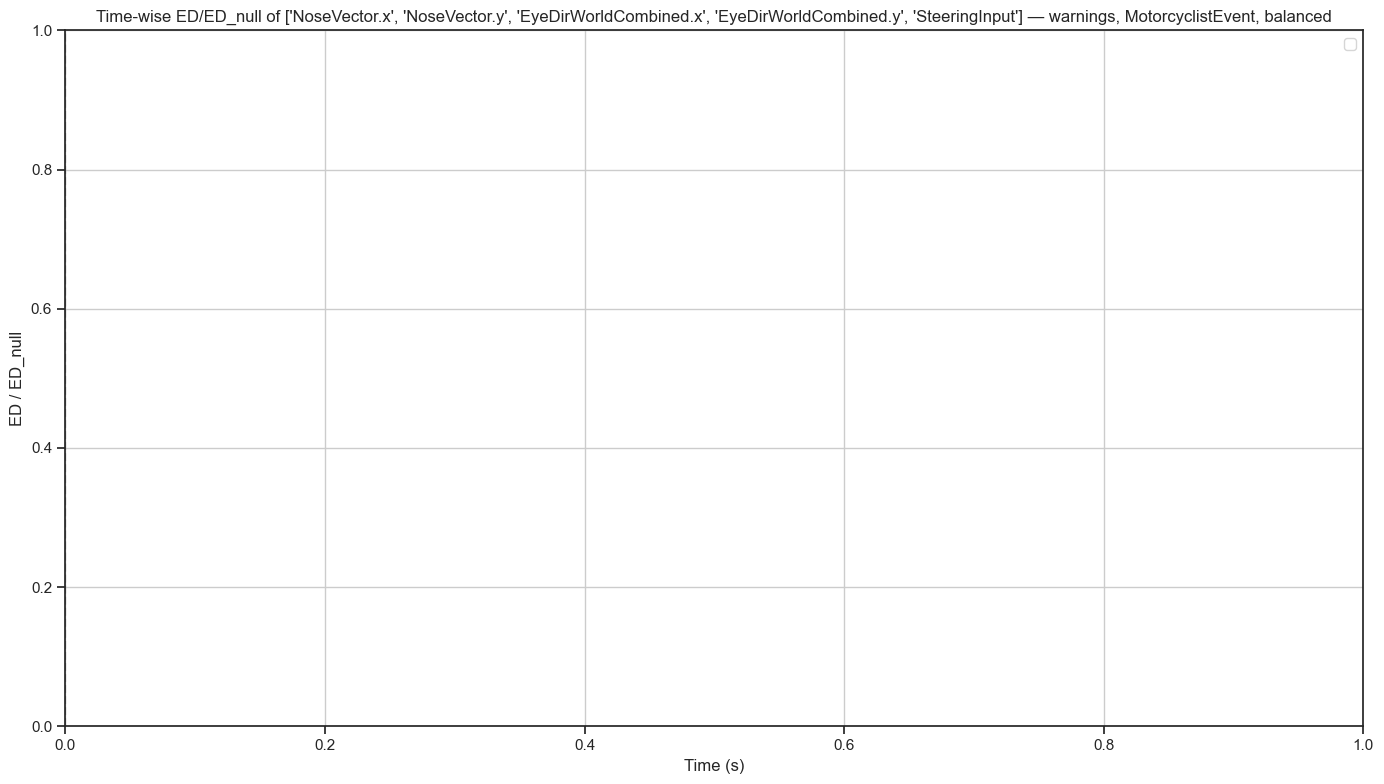

In [42]:
local_sigma = 2  # smoothing strength for local analysis (warnings)



sample_sizes, T, ed_curves, ed_null_curves = process_and_plot_ed(event_filtered_final, event_name, condition_filters,
                    modalities, points_per_window, colors,
                    analysis_mode=analysis_mode, local_sigma=local_sigma, bs_reliability=False, plot_ci=False)



permute and find significant clusters

# Between-Condition ED Comparison v2

In [43]:
# ============================================================
# Between-Condition ED Comparison v2 (corrected permutation)
# ============================================================
# Issue 1 fix: Shuffles PARTICIPANT condition labels, recomputes
#   group ED from scratch (not buffer-level value swaps).
# Issue 5 fix: Cluster threshold derived from permutation null
#   (not from pre-period baseline).
# Old function plot_ed_base_vs_aggregated_warnings() preserved
# in its original cell for comparison / reversion.

from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter1d

def compute_ed_fast(group_data, secs, steering_idx, M):
    """Vectorized ED curve. group_data: (W, T, M) -> (T,)
    Matches backup preprocessing exactly: no eigenvalue clamping, no total threshold."""
    W, T_len, _ = group_data.shape
    centered = group_data - group_data.mean(axis=0, keepdims=True)
    if steering_idx is not None:
        centered[:, secs <= 0, steering_idx] = 0.0
    stds = centered.std(axis=0, ddof=1)
    stds[stds < 1e-12] = 1.0
    normed = centered / stds
    covs = np.einsum('wti,wtj->tij', normed, normed) / (W - 1)
    ed = np.zeros(T_len)
    for t in range(T_len):
        eig = eigh(covs[t], eigvals_only=True)
        p = eig / np.sum(eig)
        ed[t] = 1.0 / np.sum(p**2)
    return ed


def plot_ed_comparison_v2(
    event_filtered_final,
    group1_conditions,
    group2_conditions,
    event_filter=None,
    smooth_sigma=2,
    n_perm=1000,
    alpha=0.05
):
    """Between-condition comparison with participant-level label permutation."""

    M = len(modalities)
    T = points_per_window
    secs = np.linspace(-5, 5, T)
    secs = np.round(secs, 2)
    steering_idx = modalities.index('SteeringInput') if 'SteeringInput' in modalities else None

    # --- Filter by event ---
    if event_filter is not None:
        if isinstance(event_filter, str):
            event_filter = [event_filter]
        df = event_filtered_final[event_filtered_final['source_event'].isin(event_filter)]
        event_str = ', '.join(event_filter)
    else:
        df = event_filtered_final
        event_str = ', '.join(df['source_event'].unique())

    # --- Build participant arrays ---
    def get_arrays(conditions):
        arrs = []
        for cond in conditions:
            if cond == '!BaseCondition':
                cdf = df[df['ExperimentalCondition'] != 'BaseCondition']
            elif cond == 'All Conditions':
                cdf = df.copy()
            else:
                cdf = df[df['ExperimentalCondition'] == cond]
            for (uid, src_evt), sub in cdf.groupby(['uid', 'source_event']):
                if len(sub) != T:
                    continue
                arrs.append(StandardScaler().fit_transform(sub[modalities].values))
        return arrs

    g1 = get_arrays(group1_conditions)
    g2 = get_arrays(group2_conditions)
    n1, n2 = len(g1), len(g2)
    g1_label = '+'.join(group1_conditions)
    g2_label = '+'.join(group2_conditions)
    print(f"Group1 ({g1_label}): {n1} participants")
    print(f"Group2 ({g2_label}): {n2} participants")

    if n1 == 0 or n2 == 0:
        print("ERROR: empty group")
        return None

    all_data = np.stack(g1 + g2, axis=0)  # (N, T, M)

    # --- Observed ---
    ed1 = compute_ed_fast(all_data[:n1], secs, steering_idx, M)
    ed2 = compute_ed_fast(all_data[n1:], secs, steering_idx, M)
    obs_diff = ed2 - ed1
    obs_diff_s = gaussian_filter1d(obs_diff, sigma=smooth_sigma) if smooth_sigma else obs_diff.copy()

    post_mask = secs >= 0
    post_time = secs[post_mask]
    diff_post = obs_diff_s[post_mask]
    n_post = len(post_time)

    # --- Permutations (participant label shuffle) ---
    print(f"\nPermuting ({n_perm} iterations, participant label shuffle)...")
    rng_perm = np.random.default_rng(seed=42)
    perm_diffs = np.zeros((n_perm, n_post))

    for i in range(n_perm):
        if i % 200 == 0:
            print(f"  {i}/{n_perm}")
        idx = rng_perm.permutation(n1 + n2)
        pe1 = compute_ed_fast(all_data[idx[:n1]], secs, steering_idx, M)
        pe2 = compute_ed_fast(all_data[idx[n1:]], secs, steering_idx, M)
        d = pe2 - pe1
        if smooth_sigma:
            d = gaussian_filter1d(d, sigma=smooth_sigma)
        perm_diffs[i] = d[post_mask]
    print(f"  {n_perm}/{n_perm}")

    # --- Threshold from permutation null (issue 5) ---
    thresh = np.percentile(np.abs(perm_diffs), 95)
    print(f"\nCluster threshold (95th %ile of null): {thresh:.4f}")

    # --- Find clusters ---
    def find_clusters(arr, thr, direction):
        mask = arr > thr if direction == 'positive' else arr < -thr
        clusters, masses = [], []
        start, csum = None, 0
        for t, v in enumerate(mask):
            if v:
                if start is None: start = t
                csum += abs(arr[t])
            else:
                if start is not None:
                    clusters.append((start, t-1))
                    masses.append(csum)
                    start, csum = None, 0
        if start is not None:
            clusters.append((start, len(arr)-1))
            masses.append(csum)
        return clusters, masses

    obs_pos_c, obs_pos_m = find_clusters(diff_post, thresh, 'positive')
    obs_neg_c, obs_neg_m = find_clusters(diff_post, thresh, 'negative')

    # Null cluster masses
    pos_null = np.array([max(find_clusters(perm_diffs[i], thresh, 'positive')[1] or [0]) for i in range(n_perm)])
    neg_null = np.array([max(find_clusters(perm_diffs[i], thresh, 'negative')[1] or [0]) for i in range(n_perm)])

    # P-values
    pos_pv = [(np.sum(pos_null >= m) + 1) / (n_perm + 1) for m in obs_pos_m]
    neg_pv = [(np.sum(neg_null >= m) + 1) / (n_perm + 1) for m in obs_neg_m]

    print(f"\nPositive clusters ({g2_label} > {g1_label}):")
    if not obs_pos_c:
        print("  (none)")
    for (s,e), mass, pv in zip(obs_pos_c, obs_pos_m, pos_pv):
        tag = " *SIG*" if pv < alpha else ""
        print(f"  [{post_time[s]:.2f}s - {post_time[e]:.2f}s] mass={mass:.3f} p={pv:.4f}{tag}")

    print(f"\nNegative clusters ({g2_label} < {g1_label}):")
    if not obs_neg_c:
        print("  (none)")
    for (s,e), mass, pv in zip(obs_neg_c, obs_neg_m, neg_pv):
        tag = " *SIG*" if pv < alpha else ""
        print(f"  [{post_time[s]:.2f}s - {post_time[e]:.2f}s] mass={mass:.3f} p={pv:.4f}{tag}")

    # --- Plotting ---
    g1_color = colors.get(group1_conditions[0], '#03071e') if len(group1_conditions) == 1 else '#03071e'
    g2_color = colors.get(group2_conditions[0], '#0a25c0') if len(group2_conditions) == 1 else '#0a25c0'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: ED curves
    ax = axes[0, 0]
    se1 = gaussian_filter1d(ed1, sigma=smooth_sigma) if smooth_sigma else ed1
    se2 = gaussian_filter1d(ed2, sigma=smooth_sigma) if smooth_sigma else ed2
    ax.plot(secs, ed1, color=g1_color, alpha=0.2, linewidth=1)
    ax.plot(secs, se1, color=g1_color, linewidth=2, label=g1_label)
    ax.plot(secs, ed2, color=g2_color, alpha=0.2, linewidth=1)
    ax.plot(secs, se2, color=g2_color, linewidth=2, label=g2_label)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ED')
    ax.set_title('ED Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 2: Difference + clusters
    ax = axes[0, 1]
    ax.plot(secs, obs_diff, color='gray', alpha=0.3, linewidth=1)
    ax.plot(secs, obs_diff_s, color='black', linewidth=2, label='Smoothed diff')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(thresh, color='orange', linestyle=':', linewidth=2, label=f'Threshold (+/-{thresh:.3f})')
    ax.axhline(-thresh, color='orange', linestyle=':', linewidth=2)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    for (s,e), pv in zip(obs_pos_c, pos_pv):
        c = 'lightblue' if pv < alpha else 'lightgray'
        ax.axvspan(post_time[s], post_time[e], color=c, alpha=0.4 if pv < alpha else 0.15)
        if pv < alpha:
            ax.text((post_time[s]+post_time[e])/2, thresh*1.05, f'p={pv:.4f}',
                    ha='center', fontsize=9, color='blue', fontweight='bold')
    for (s,e), pv in zip(obs_neg_c, neg_pv):
        c = 'steelblue' if pv < alpha else 'lightgray'
        ax.axvspan(post_time[s], post_time[e], color=c, alpha=0.4 if pv < alpha else 0.15)
        if pv < alpha:
            ax.text((post_time[s]+post_time[e])/2, -thresh*1.05, f'p={pv:.4f}',
                    ha='center', fontsize=9, color='darkblue', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'ED diff ({g2_label} - {g1_label})')
    ax.set_title('Difference + Clusters')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 3: Null distribution
    ax = axes[1, 0]
    pn95 = np.percentile(pos_null, 95)
    ax.hist(pos_null, bins=40, alpha=0.6, color='lightblue', edgecolor='black')
    ax.axvline(pn95, color='blue', linestyle='--', linewidth=2, label=f'95th %ile={pn95:.2f}')
    for mass in obs_pos_m:
        ax.axvline(mass, color='darkblue', linewidth=2, alpha=0.7)
    ax.set_xlabel('Max cluster mass')
    ax.set_ylabel('Count')
    ax.set_title('Null dist (positive clusters)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 4: Summary table
    ax = axes[1, 1]
    ax.axis('off')
    rows = []
    for (s,e), mass, pv in zip(obs_pos_c, obs_pos_m, pos_pv):
        rows.append(['+', f'{post_time[s]:.2f}', f'{post_time[e]:.2f}',
                     f'{post_time[e]-post_time[s]:.2f}', f'{mass:.3f}', f'{pv:.4f}',
                     'YES' if pv < alpha else 'NO'])
    for (s,e), mass, pv in zip(obs_neg_c, obs_neg_m, neg_pv):
        rows.append(['-', f'{post_time[s]:.2f}', f'{post_time[e]:.2f}',
                     f'{post_time[e]-post_time[s]:.2f}', f'{mass:.3f}', f'{pv:.4f}',
                     'YES' if pv < alpha else 'NO'])
    if rows:
        tbl = ax.table(cellText=rows,
                       colLabels=['Dir','Start','End','Dur','Mass','p','Sig'],
                       cellLoc='center', loc='center', bbox=[0,0,1,1])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 2)
        for j in range(7):
            tbl[(0,j)].set_facecolor('#4CAF50')
            tbl[(0,j)].set_text_props(weight='bold', color='white')
        n_sig = sum(1 for r in rows if r[6]=='YES')
        ax.set_title(f'{len(rows)} clusters, {n_sig} significant', fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No clusters', ha='center', va='center', fontsize=14, transform=ax.transAxes)

    # event_str already set above from event_filter param
    plt.suptitle(f'{g2_label} vs {g1_label} | n_perm={n_perm}, participant shuffle | {event_str}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'obs_pos_clusters': obs_pos_c, 'obs_neg_clusters': obs_neg_c,
        'pos_pvals': pos_pv, 'neg_pvals': neg_pv,
        'ed1': ed1, 'ed2': ed2, 'diff': obs_diff_s,
        'threshold': thresh, 'time': secs,
    }

Group1 (BaseCondition): 109 participants
Group2 (HUDOnly): 111 participants

Permuting (1000 iterations, participant label shuffle)...
  0/1000
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000

Cluster threshold (95th %ile of null): 0.4308

Positive clusters (HUDOnly > BaseCondition):
  [0.12s - 0.46s] mass=14.034 p=0.0390 *SIG*

Negative clusters (HUDOnly < BaseCondition):
  (none)


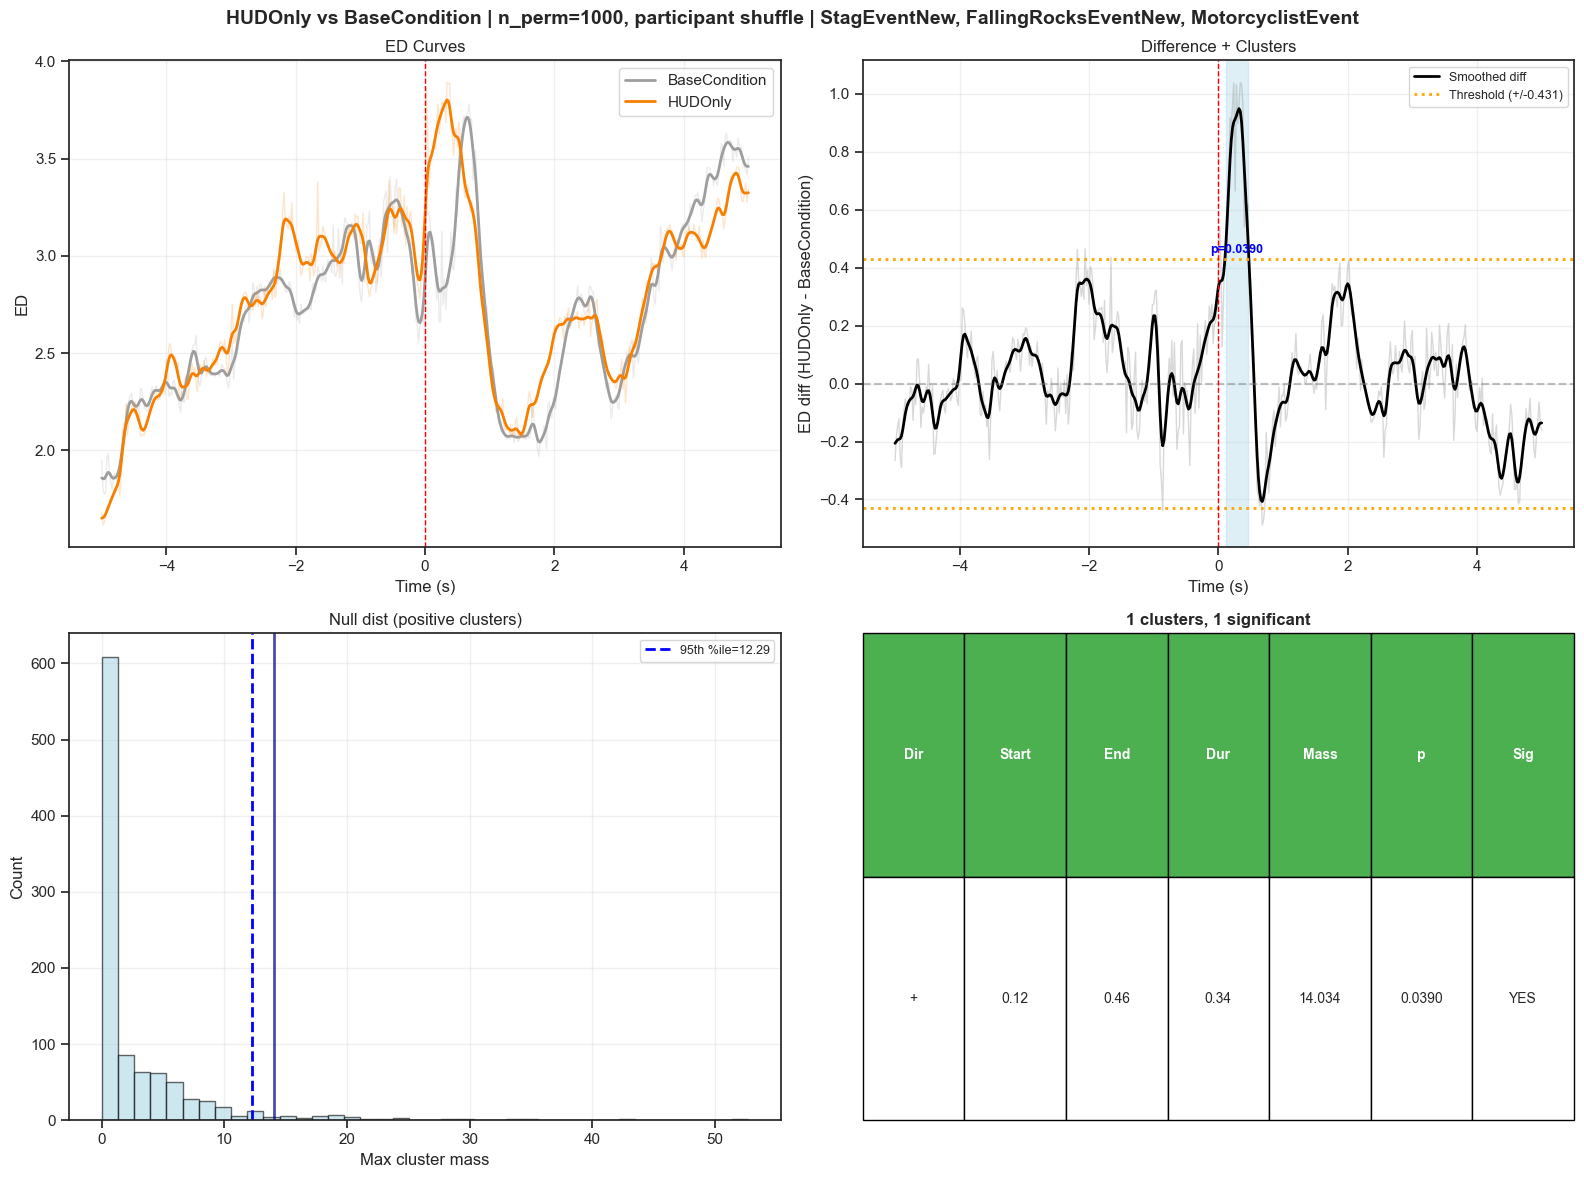

In [44]:
# Usage: corrected between-condition comparison
results_v2 = plot_ed_comparison_v2(
    event_filtered_final,
    group1_conditions=['BaseCondition'],
    group2_conditions=['HUDOnly'],
    smooth_sigma=2,
    n_perm=1000,
    alpha=0.05
)

# TFCE-based Between-Condition ED Comparison


In [45]:
# ============================================================
# TFCE-based Between-Condition ED Comparison
# (Smith & Nichols, NeuroImage 2009)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, label
from scipy.linalg import eigh
from sklearn.preprocessing import StandardScaler


def tfce_1d(arr, dh=None, E=0.5, H=2.0):
    """Threshold-Free Cluster Enhancement for 1D.
    Positive values only; call on -arr for negative direction.
    E=0.5, H=2.0 are Smith & Nichols 2009 defaults."""
    tfce = np.zeros_like(arr, dtype=float)
    max_val = arr.max()
    if max_val <= 0:
        return tfce
    if dh is None:
        dh = max_val / 100
    h = dh
    while h <= max_val + dh / 2:
        mask = arr >= h
        labeled, n_clusters = label(mask)
        for c in range(1, n_clusters + 1):
            cluster_mask = labeled == c
            extent = cluster_mask.sum()
            tfce[cluster_mask] += (extent ** E) * (h ** H) * dh
        h += dh
    return tfce


def plot_ed_comparison_tfce(
    event_filtered_final,
    group1_conditions,
    group2_conditions,
    event_filter=None,
    smooth_sigma=2,
    n_perm=1000,
    alpha=0.05,
    tfce_E=0.5,
    tfce_H=2.0,
):
    """
    Between-condition ED comparison using TFCE + participant-level permutation.
    TFCE replaces the arbitrary cluster-forming threshold with integration
    over all thresholds, weighting by cluster extent and height.
    FWER correction via max-statistic across the permutation null.
    """
    M = len(modalities)
    T = points_per_window
    secs = np.linspace(-5, 5, T)
    secs = np.round(secs, 2)
    steering_idx = modalities.index('SteeringInput') if 'SteeringInput' in modalities else None

    # --- Filter by event ---
    if event_filter is not None:
        if isinstance(event_filter, str):
            event_filter = [event_filter]
        df = event_filtered_final[event_filtered_final['source_event'].isin(event_filter)]
        event_str = ', '.join(event_filter)
    else:
        df = event_filtered_final
        event_str = ', '.join(df['source_event'].unique())

    print(f"Data: {len(df)} rows, events={df['EventName'].unique()}, conditions={df['ExperimentalCondition'].unique()}")
    sizes = df.groupby(['uid', 'EventName']).size()
    print(f"Group sizes: min={sizes.min()}, max={sizes.max()}, median={sizes.median()}, T={T}")
    print(f"Groups with exactly T rows: {(sizes == T).sum()} / {len(sizes)}")

    def get_arrays(conditions):
        arrs = []
        for cond in conditions:
            if cond == '!BaseCondition':
                cdf = df[df['ExperimentalCondition'] != 'BaseCondition']
            elif cond == 'All Conditions':
                cdf = df.copy()
            else:
                cdf = df[df['ExperimentalCondition'] == cond]
            for (uid, src_evt), sub in cdf.groupby(['uid', 'source_event']):
                if len(sub) != T:
                    continue
                arrs.append(StandardScaler().fit_transform(sub[modalities].values))
        return arrs

    g1 = get_arrays(group1_conditions)
    g2 = get_arrays(group2_conditions)
    n1, n2 = len(g1), len(g2)
    g1_label = '+'.join(group1_conditions)
    g2_label = '+'.join(group2_conditions)
    print(f'Group1 ({g1_label}): {n1} participants')
    print(f'Group2 ({g2_label}): {n2} participants')

    if n1 == 0 or n2 == 0:
        print('ERROR: empty group')
        return None

    all_data = np.stack(g1 + g2, axis=0)

    # --- Observed ED ---
    ed1 = compute_ed_fast(all_data[:n1], secs, steering_idx, M)
    ed2 = compute_ed_fast(all_data[n1:], secs, steering_idx, M)
    obs_diff = ed2 - ed1
    obs_diff_s = gaussian_filter1d(obs_diff, sigma=smooth_sigma) if smooth_sigma else obs_diff.copy()

    post_mask = secs >= 0
    post_time = secs[post_mask]
    diff_post = obs_diff_s[post_mask]
    n_post = len(post_time)

    # --- Observed TFCE ---
    obs_tfce_pos = tfce_1d(diff_post, E=tfce_E, H=tfce_H)
    obs_tfce_neg = tfce_1d(-diff_post, E=tfce_E, H=tfce_H)

    # --- Permutations ---
    print(f'\nTFCE permutation test ({n_perm} iterations, participant label shuffle)')
    print(f'  E={tfce_E}, H={tfce_H}')
    rng_perm = np.random.default_rng(seed=42)

    null_max_pos = np.zeros(n_perm)
    null_max_neg = np.zeros(n_perm)

    for i in range(n_perm):
        if i % 200 == 0:
            print(f'  {i}/{n_perm}')
        idx = rng_perm.permutation(n1 + n2)
        pe1 = compute_ed_fast(all_data[idx[:n1]], secs, steering_idx, M)
        pe2 = compute_ed_fast(all_data[idx[n1:]], secs, steering_idx, M)
        d = pe2 - pe1
        if smooth_sigma:
            d = gaussian_filter1d(d, sigma=smooth_sigma)
        d_post = d[post_mask]

        perm_pos = tfce_1d(d_post, E=tfce_E, H=tfce_H)
        perm_neg = tfce_1d(-d_post, E=tfce_E, H=tfce_H)

        null_max_pos[i] = perm_pos.max() if perm_pos.max() > 0 else 0
        null_max_neg[i] = perm_neg.max() if perm_neg.max() > 0 else 0
    print(f'  {n_perm}/{n_perm}')

    # --- FWER-corrected p-values (max statistic) ---
    pvals_pos = np.array([(np.sum(null_max_pos >= obs_tfce_pos[t]) + 1) / (n_perm + 1)
                          for t in range(n_post)])
    pvals_neg = np.array([(np.sum(null_max_neg >= obs_tfce_neg[t]) + 1) / (n_perm + 1)
                          for t in range(n_post)])

    sig_pos = pvals_pos < alpha
    sig_neg = pvals_neg < alpha

    # --- Find contiguous significant regions ---
    def find_sig_regions(sig_mask, times, pvals):
        regions = []
        start = None
        for i, s in enumerate(sig_mask):
            if s and start is None:
                start = i
            elif not s and start is not None:
                regions.append((times[start], times[i - 1], pvals[start:i].min()))
                start = None
        if start is not None:
            regions.append((times[start], times[-1], pvals[start:].min()))
        return regions

    pos_regions = find_sig_regions(sig_pos, post_time, pvals_pos)
    neg_regions = find_sig_regions(sig_neg, post_time, pvals_neg)

    # --- Print results ---
    print(f'\nSignificant regions ({g2_label} > {g1_label}): {len(pos_regions)}')
    for s, e, p in pos_regions:
        print(f'  [{s:.2f}s - {e:.2f}s] min p={p:.4f}')

    print(f'Significant regions ({g2_label} < {g1_label}): {len(neg_regions)}')
    for s, e, p in neg_regions:
        print(f'  [{s:.2f}s - {e:.2f}s] min p={p:.4f}')

    if not pos_regions and not neg_regions:
        print('  No significant timepoints found')

    # --- Plotting ---
    g1_color = colors.get(group1_conditions[0], '#03071e') if len(group1_conditions) == 1 else '#03071e'
    g2_color = colors.get(group2_conditions[0], '#0a25c0') if len(group2_conditions) == 1 else '#0a25c0'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: ED curves with significant regions
    ax = axes[0, 0]
    se1 = gaussian_filter1d(ed1, sigma=smooth_sigma) if smooth_sigma else ed1
    se2 = gaussian_filter1d(ed2, sigma=smooth_sigma) if smooth_sigma else ed2
    ax.plot(secs, ed1, color=g1_color, alpha=0.2, linewidth=1)
    ax.plot(secs, se1, color=g1_color, linewidth=2, label=g1_label)
    ax.plot(secs, ed2, color=g2_color, alpha=0.2, linewidth=1)
    ax.plot(secs, se2, color=g2_color, linewidth=2, label=g2_label)
    for s, e, p in pos_regions + neg_regions:
        ax.axvspan(s, e, color='gold', alpha=0.35)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ED')
    ax.set_title('ED Curves (gold = TFCE significant)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 2: Difference curve with TFCE significance
    ax = axes[0, 1]
    ax.plot(post_time, diff_post, color='black', linewidth=2, label='Smoothed diff')
    ax.fill_between(post_time, diff_post, 0, where=sig_pos,
                    color='steelblue', alpha=0.4, label=f'Sig + (p<{alpha})')
    ax.fill_between(post_time, diff_post, 0, where=sig_neg,
                    color='coral', alpha=0.4, label=f'Sig - (p<{alpha})')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'ED diff ({g2_label} - {g1_label})')
    ax.set_title('Difference + TFCE significance')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 3: TFCE scores with threshold
    ax = axes[1, 0]
    ax.plot(post_time, obs_tfce_pos, color='steelblue', linewidth=2, label='TFCE+ (observed)')
    ax.plot(post_time, obs_tfce_neg, color='coral', linewidth=2, label='TFCE- (observed)')
    p_thresh_pos = np.percentile(null_max_pos, 100 * (1 - alpha))
    p_thresh_neg = np.percentile(null_max_neg, 100 * (1 - alpha))
    ax.axhline(p_thresh_pos, color='steelblue', linestyle=':', linewidth=2,
               label=f'{int(100*(1-alpha))}th null+ ({p_thresh_pos:.1f})')
    ax.axhline(p_thresh_neg, color='coral', linestyle=':', linewidth=2,
               label=f'{int(100*(1-alpha))}th null- ({p_thresh_neg:.1f})')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('TFCE score')
    ax.set_title('TFCE Scores vs Null Threshold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 4: Null distribution of max TFCE
    ax = axes[1, 1]
    ax.hist(null_max_pos, bins=40, alpha=0.5, color='steelblue', edgecolor='black', label='Null max TFCE+')
    ax.hist(null_max_neg, bins=40, alpha=0.5, color='coral', edgecolor='black', label='Null max TFCE-')
    obs_max_pos = obs_tfce_pos.max()
    obs_max_neg = obs_tfce_neg.max()
    ax.axvline(obs_max_pos, color='darkblue', linewidth=2, linestyle='--',
               label=f'Obs max+ ({obs_max_pos:.1f})')
    ax.axvline(obs_max_neg, color='darkred', linewidth=2, linestyle='--',
               label=f'Obs max- ({obs_max_neg:.1f})')
    ax.set_xlabel('Max TFCE score')
    ax.set_ylabel('Count')
    ax.set_title('Null Distribution of Max TFCE')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # event_str already set above from event_filter param
    plt.suptitle(f'TFCE: {g2_label} vs {g1_label} | n_perm={n_perm} | {event_str}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'pvals_pos': pvals_pos, 'pvals_neg': pvals_neg,
        'sig_pos': sig_pos, 'sig_neg': sig_neg,
        'tfce_pos': obs_tfce_pos, 'tfce_neg': obs_tfce_neg,
        'ed1': ed1, 'ed2': ed2, 'diff': obs_diff_s,
        'time': secs, 'post_time': post_time,
        'null_max_pos': null_max_pos, 'null_max_neg': null_max_neg,
        'pos_regions': pos_regions, 'neg_regions': neg_regions,
    }


Data: 110220 rows, events=<ArrowStringArray>
['NoEvent', 'StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']
Length: 4, dtype: string, conditions=<ArrowStringArray>
['BaseCondition', 'HUDOnly']
Length: 2, dtype: string
Group sizes: min=162, max=867, median=251.0, T=501
Groups with exactly T rows: 0 / 294
Group1 (BaseCondition): 109 participants
Group2 (HUDOnly): 111 participants

TFCE permutation test (1000 iterations, participant label shuffle)
  E=0.5, H=2.0
  0/1000
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000

Significant regions (HUDOnly > BaseCondition): 1
  [0.18s - 0.40s] min p=0.0080
Significant regions (HUDOnly < BaseCondition): 0


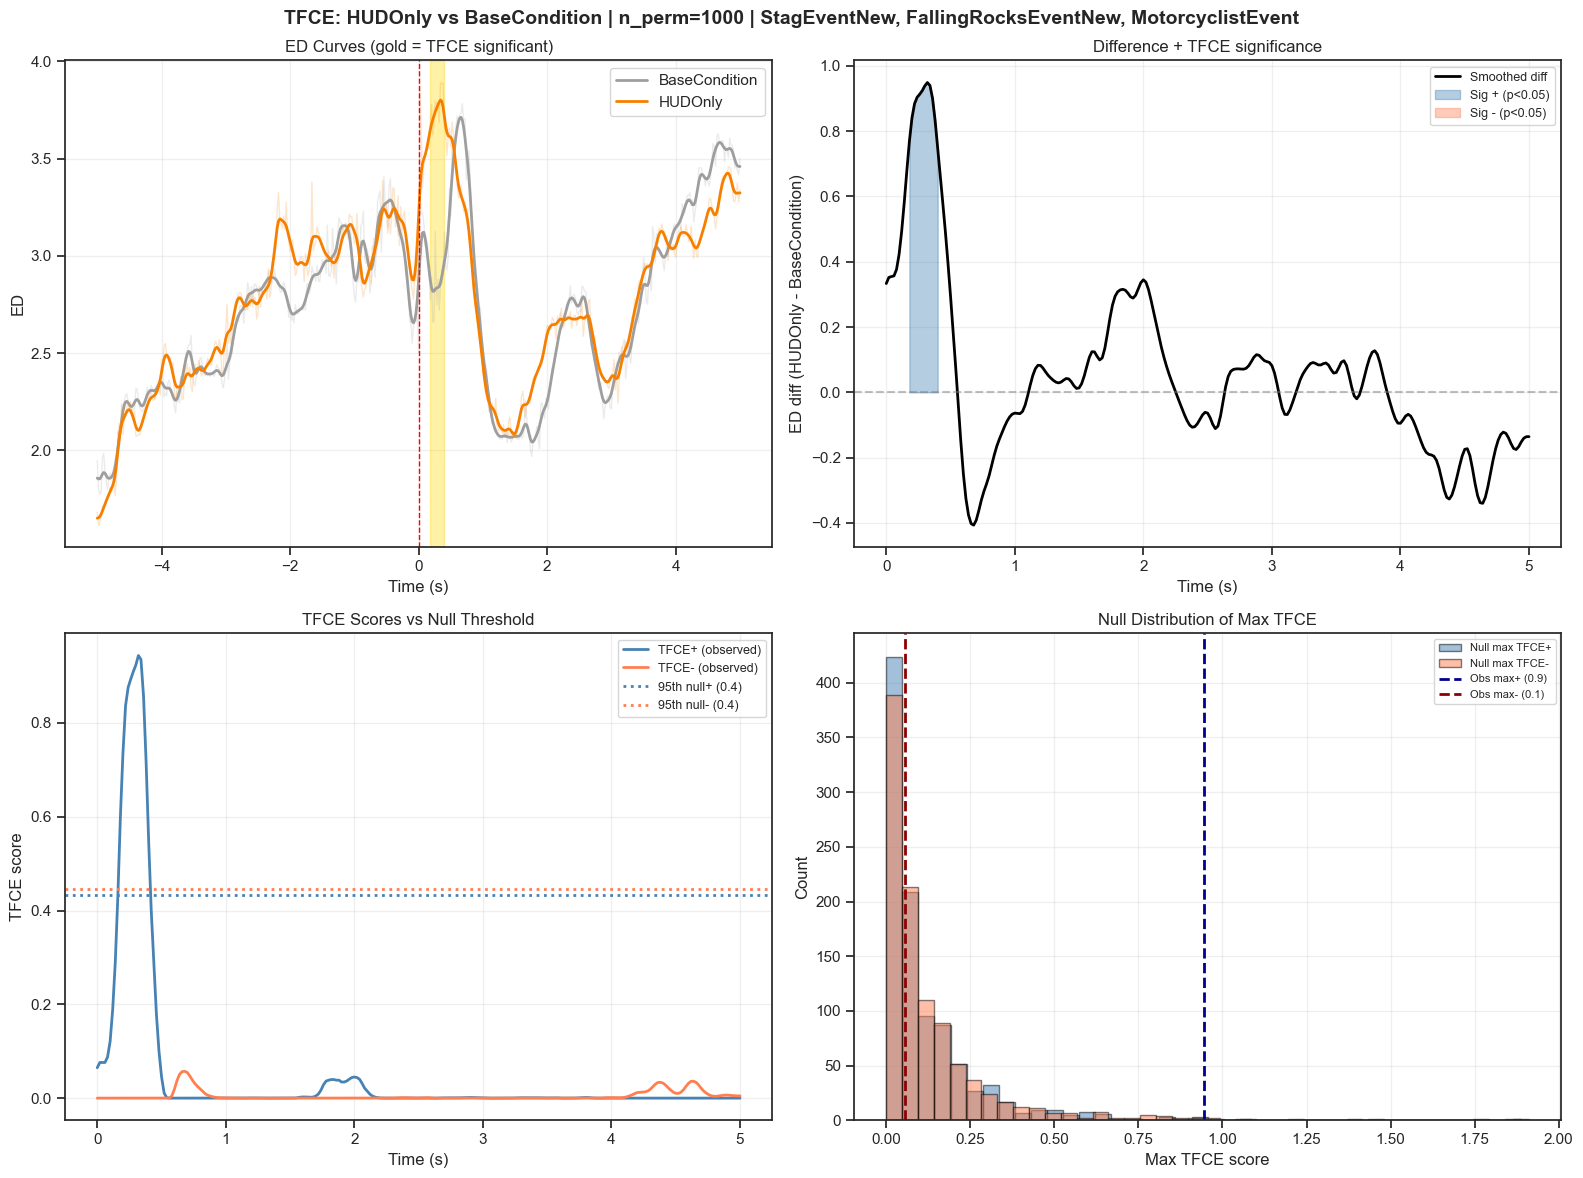

In [46]:
# Run TFCE comparison - single event
results_tfce = plot_ed_comparison_tfce(
    event_filtered_final,
    group1_conditions=['BaseCondition'],
    group2_conditions=['HUDOnly'],
    smooth_sigma=2,
    n_perm=1000,
    alpha=0.05,
)

Participants: 109
Max absolute difference: 3.55e-15
ED fast range: [1.777, 3.782]
ED loop range: [1.777, 3.782]


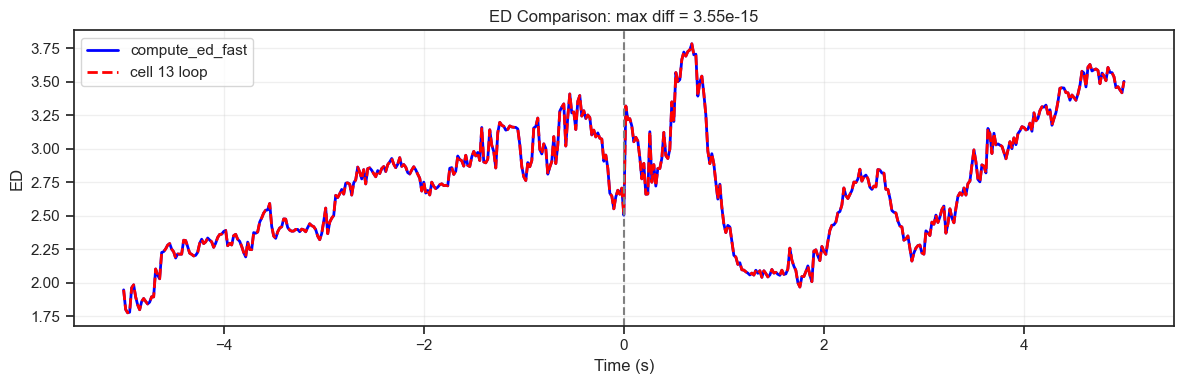

In [47]:
# DEBUG: Compare compute_ed_fast vs cell 13 loop
# Run this after cells 2,4,9,11 to verify ED computation
from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
import numpy as np

M = len(modalities)
T = points_per_window
secs = np.linspace(-5, 5, T)
secs = np.round(secs, 2)
steering_idx = modalities.index('SteeringInput') if 'SteeringInput' in modalities else None

# Build data for one condition (same as both functions do)
cdf = event_filtered_final[event_filtered_final['ExperimentalCondition'] == 'BaseCondition']
curves = []
for (uid, src_evt), sub in cdf.groupby(['uid', 'source_event']):
    if len(sub) != T:
        continue
    curves.append(StandardScaler().fit_transform(sub[modalities].values))
print(f"Participants: {len(curves)}")

# Stack to (W, T, M)
group_data = np.stack(curves, axis=0)
W = group_data.shape[0]

# --- Method 1: compute_ed_fast ---
ed_fast = compute_ed_fast(group_data, secs, steering_idx, M)

# --- Method 2: cell 13 explicit loop (matches backup: no clamping, no total check) ---
Pca_data_array = group_data.copy()
ed_loop = []
for t in range(T):
    snap = Pca_data_array[:, t, :].copy()  # COPY to avoid in-place issues
    snap -= snap.mean(axis=0)
    if secs[t] <= 0 and steering_idx is not None:
        snap[:, steering_idx] = 0
    for m in range(M):
        if steering_idx is not None and m == steering_idx and secs[t] <= 0:
            continue
        std = snap[:, m].std(ddof=1)
        if std > 1e-12:
            snap[:, m] /= std
    cov = snap.T @ snap / (W - 1)
    eig = eigh(cov, eigvals_only=True)
    p = eig / np.sum(eig)
    ed_loop.append(1.0 / np.sum(p**2))
ed_loop = np.array(ed_loop)

# --- Compare ---
max_diff = np.max(np.abs(ed_fast - ed_loop))
print(f"Max absolute difference: {max_diff:.2e}")
print(f"ED fast range: [{ed_fast.min():.3f}, {ed_fast.max():.3f}]")
print(f"ED loop range: [{ed_loop.min():.3f}, {ed_loop.max():.3f}]")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(secs, ed_fast, 'b-', linewidth=2, label='compute_ed_fast')
ax.plot(secs, ed_loop, 'r--', linewidth=2, label='cell 13 loop')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('ED')
ax.set_title(f'ED Comparison: max diff = {max_diff:.2e}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()